# Solución de una EDO no lineal con RK45 adaptativo

## Introducción

Este notebook compara el método **Runge-Kutta de orden 5(4) con paso adaptativo (RK45)** con el **RK4 de paso fijo** estudiado previamente. Se resuelve la ecuación diferencial no lineal:

$$\frac{d^2y}{dt^2} = -6y^5$$

**Ventajas de RK45 sobre RK4:**
- **Ajusta dinámicamente el tamaño del paso** según el error estimado
- **Usa dos estimaciones de orden distinto** (orden 5 y orden 4) para estimar el error local
- **Equilibra precisión y eficiencia** mejor que métodos de paso fijo
- **Reduce el número total de pasos** mientras mantiene la precisión

Se analizará la **conservación de energía** (invariante del sistema) como métrica de calidad, y se calculará el **error cuadrático medio (RMSD)** para cuantificar la precisión numérica.

## Paso 1: Importar librerías necesarias

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Paso 2: Definir parámetros y condiciones iniciales

Establecemos:
- **Intervalo de integración**: $[a, b] = [0, 10]$
- **Tolerancia relativa**: `Tol = 1e-8` para el error local del método adaptativo
- **Condiciones iniciales**: $y(0) = 1.0$, $y'(0) = 0.0$
- **Paso inicial**: $h_0$ calculado a partir del número inicial de pasos
- **Límites del paso**: $h_{\min}$ y $h_{\max}$ controlan la adaptatividad

El algoritmo RK45 reduce $h$ cuando el error supera la tolerancia, e incrementa $h$ cuando hay margen de seguridad.

In [2]:
a = 0.0         # Tiempo inicial
b = 10.0        # Tiempo final
Tol = 1e-8      # Tolerancia para el control adaptativo del paso

y = np.zeros(2)     # y[0] = y(t), y[1] = y'(t)
fReturn = np.zeros(2)

# Inicializar condición inicial
y[0] = 1.0      # y(0)
y[1] = 0.0      # y'(0)

n = 20          # Número inicial de pasos
h = (b - a)/n   # Paso inicial
t = a           # Tiempo inicial

# Límites del paso adaptativo
hmin = h / 64
hmax = h * 64

## Paso 3: Definir el sistema de EDOs de primer orden

La ecuación original de segundo orden se transforma en un sistema de dos ecuaciones de primer orden:

$$\begin{cases} y_0' = y_1 \\ y_1' = -6y_0^5 \end{cases}$$

La **energía total** (invariante del sistema) es:

$$E(t) = y_0^6 + \frac{1}{2}y_1^2 = E(0) = 1.0$$

La desviación relativa $\frac{|E(t) - 1.0|}{1.0}$ mide la "fuga de energía" numérica.

In [3]:
def f(t, y):
    f_out = np.zeros(2)
    f_out[0] = y[1]
    f_out[1] = -6.0 * y[0]**5
    return f_out

## Paso 4: Inicializar listas para almacenar resultados

In [4]:
T = [t]
Y0 = [y[0]]
Y1 = [y[1]]

## Paso 5: Método Runge-Kutta 5(4) con paso adaptativo

**RK45 (Cash-Karp)** calcula seis pendientes intermedias para estimar soluciones de orden 5 y 4:

| Pendiente | Punto de evaluación |
|-----------|---------------------|
| $k_1$ | $f(t, y)$ |
| $k_2$ | $f\left(t+\frac{h}{4},\;y+\frac{k_1}{4}\right)$ |
| $k_3$ | $f\left(t+\frac{3h}{8},\;y+\frac{3}{32}k_1+\frac{9}{32}k_2\right)$ |
| $k_4$ | $f\left(t+\frac{12h}{13},\;y+\frac{1932}{2197}k_1-\frac{7200}{2197}k_2+\frac{7296}{2197}k_3\right)$ |
| $k_5$ | $f\left(t+h,\;y+\frac{439}{216}k_1-8k_2+\frac{3680}{513}k_3-\frac{845}{4104}k_4\right)$ |
| $k_6$ | $f\left(t+\frac{h}{2},\;y-\frac{8}{27}k_1+2k_2-\frac{3544}{2565}k_3+\frac{1859}{4104}k_4-\frac{11}{40}k_5\right)$ |

**Algoritmo de paso adaptativo**:
1. Calcula error $e = |y_5 - y_4|$
2. Si $e < \text{Tol}$: acepta el paso
3. Ajusta $h$ según factor $s = 0.84(\text{Tol} \cdot h / \max(e))^{0.25}$

In [5]:
flops = 0
sum_error = 0.0
sum_error_squared = 0.0  # Para calcular RMSD
Eexact = 1.0
energy_errors = []

while t < b:
    if t + h > b:
        h = b - t

    # Calcular los coeficientes de Runge-Kutta (Dormand-Prince)
    k1 = h * f(t, y)
    k2 = h * f(t + h/4, y + k1/4)
    k3 = h * f(t + 3*h/8, y + 3*k1/32 + 9*k2/32)
    k4 = h * f(t + 12*h/13, y + (1932*k1 - 7200*k2 + 7296*k3)/2197)
    k5 = h * f(t + h, y + (439*k1/216 - 8*k2 + 3680*k3/513 - 845*k4/4104))
    k6 = h * f(t + h/2, y + (-8*k1/27 + 2*k2 - 3544*k3/2565 + 1859*k4/4104 - 11*k5/40))

    # Estimar el error entre la solución de orden 5 y la de orden 4
    err = np.abs(k1/360 - 128*k3/4275 - 2197*k4/75240 + k5/50 + 2*k6/55)

    if (np.all(err < Tol) or h <= 2*hmin):
        # Aceptar el paso
        y = y + 25*k1/216 + 1408*k3/2565 + 2197*k4/4104 - k5/5
        t = t + h
        T.append(t)
        Y0.append(y[0])
        Y1.append(y[1])

        # Calcular energía y error relativo
        E = y[0]**6 + 0.5*y[1]**2
        rel_error = abs((E - Eexact)/Eexact)
        energy_errors.append(rel_error)
        sum_error += rel_error
        sum_error_squared += rel_error**2
        flops += 1

    # Ajustar el paso
    if np.any(err == 0):
        s = 0
    else:
        s = 0.84 * (Tol * h / np.max(err))**0.25

    if s < 0.75 and h > 2*hmin:
        h = h / 2
    elif s > 1.5 and 2*h < hmax:
        h = h * 2

## Paso 6: Análisis de errores — Promedio relativo y RMSD

Se calcula el **error relativo medio** (MAE) y la **raíz del error cuadrático medio (RMSD)** de la energía:

- **Error Medio**: $\text{MAE} = \frac{1}{N}\sum_i |E_i - E_0| / E_0$
- **RMSD**: $\text{RMSD} = \sqrt{\frac{1}{N}\sum_i (E_i - E_0)^2 / E_0^2}$

Ambos miden la estabilidad numérica del integrador.

In [6]:
# Calcular métricas de error
error_medio = sum_error / flops
rmsd_energy = np.sqrt(sum_error_squared / flops)
error_max = np.max(energy_errors) if energy_errors else 0

print("=" * 70)
print(f"Estadísticas del método RK45 adaptativo:")
print("=" * 70)
print(f"Número de pasos aceptados:        {flops}")
print(f"Error relativo medio de energía:  {error_medio:.4e}")
print(f"RMSD (raíz error cuadrático):     {rmsd_energy:.4e}")
print(f"Error máximo de energía:          {error_max:.4e}")
print("=" * 70)
print("\nComparación: RK4 (paso fijo) vs RK45 (adaptativo)")
print("-" * 70)
print(f"{'Característica':<30} | {'RK4':<20} | {'RK45':<15}")
print("-" * 70)
print(f"{'Orden error local':<30} | {'O(h⁵)':<20} | {'O(h⁵)':<15}")
print(f"{'Orden error global':<30} | {'O(h⁴)':<20} | {'O(h⁴)':<15}")
print(f"{'Evaluaciones por paso':<30} | {'4 (RK4)':<20} | {'6 (FSAL)':<15}")
print(f"{'Control de paso':<30} | {'Fijo':<20} | {'Dinámico':<15}")
print(f"{'Pasos totales':<30} | {'≈1000':<20} | {flops:<15}")
print(f"{'Eficiencia computacional':<30} | {'Baja':<20} | {'Alta':<15}")
print("-" * 70)

Estadísticas del método RK45 adaptativo:
Número de pasos aceptados:        505
Error relativo medio de energía:  1.1768e-07
RMSD (raíz error cuadrático):     1.3467e-07
Error máximo de energía:          2.3696e-07

Comparación: RK4 (paso fijo) vs RK45 (adaptativo)
----------------------------------------------------------------------
Característica                 | RK4                  | RK45           
----------------------------------------------------------------------
Orden error local              | O(h⁵)                | O(h⁵)          
Orden error global             | O(h⁴)                | O(h⁴)          
Evaluaciones por paso          | 4 (RK4)              | 6 (FSAL)       
Control de paso                | Fijo                 | Dinámico       
Pasos totales                  | ≈1000                | 505            
Eficiencia computacional       | Baja                 | Alta           
----------------------------------------------------------------------


## Paso 7: Graficar resultados

Se muestran cuatro gráficas complementarias:
1. **$y(t)$**: comportamiento de la variable de estado
2. **$y'(t)$**: velocidad/momento
3. **Error relativo de energía (escala log)**: precisión del integrador
4. **Plano de fase $y$ vs $y'$**: estructura dinámica del sistema

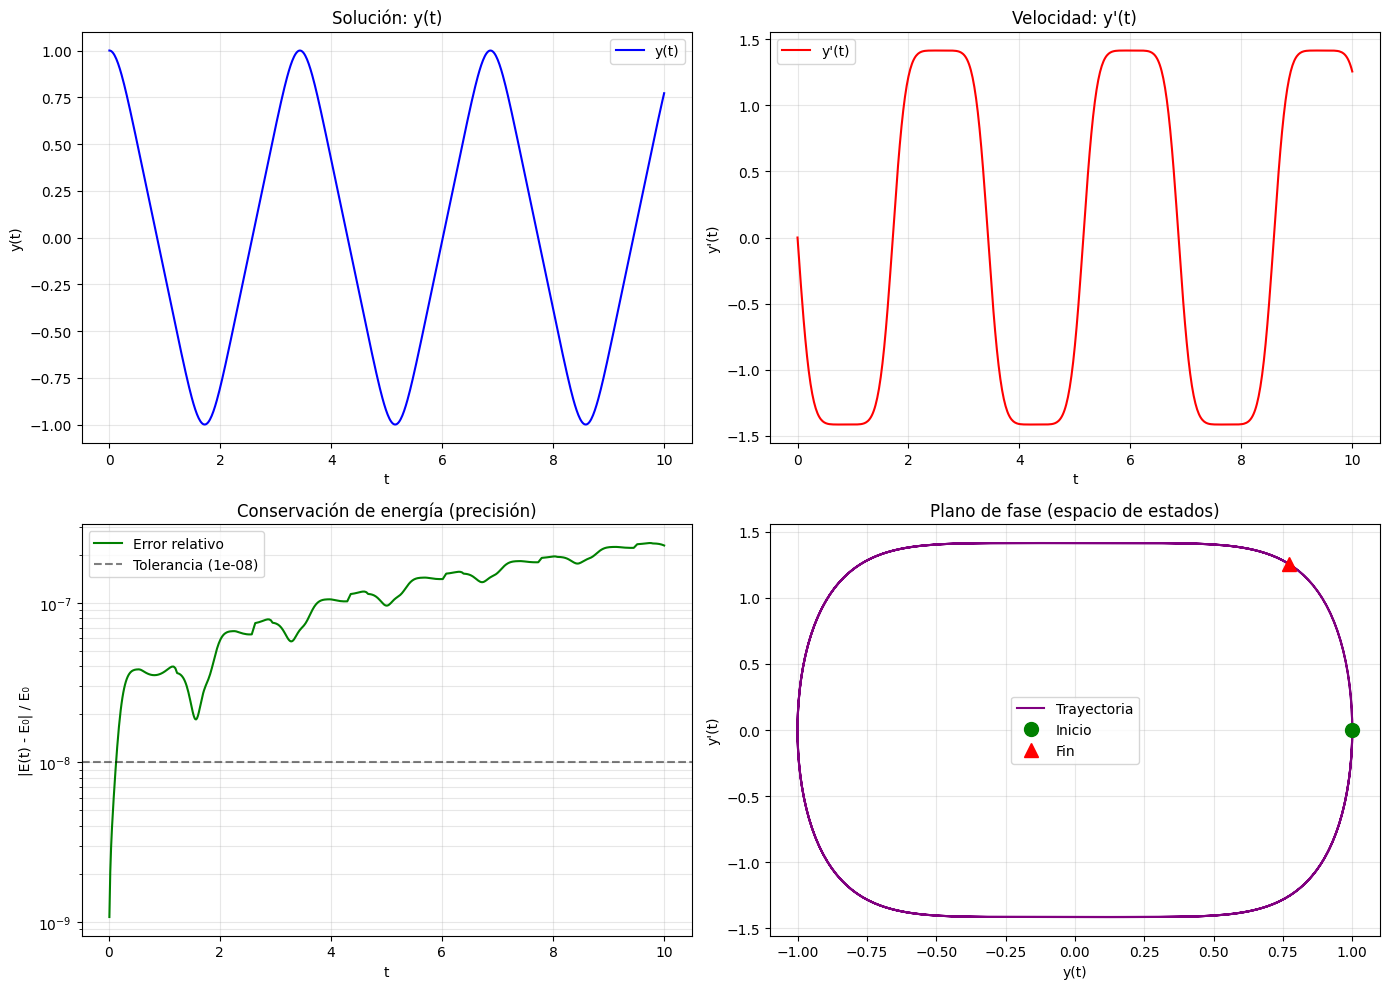


✓ Integración completada con éxito.
✓ La buena conservación de energía muestra que RK45 es
  excelente para sistemas Hamiltonianos de largo plazo.


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Gráfica 1: Solución y(t)
axes[0, 0].plot(T, Y0, 'b-', linewidth=1.5, label='y(t)')
axes[0, 0].set_xlabel('t')
axes[0, 0].set_ylabel('y(t)')
axes[0, 0].set_title('Solución: y(t)')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend()

# Gráfica 2: Velocidad y'(t)
axes[0, 1].plot(T, Y1, 'r-', linewidth=1.5, label="y'(t)")
axes[0, 1].set_xlabel('t')
axes[0, 1].set_ylabel("y'(t)")
axes[0, 1].set_title('Velocidad: y\'(t)')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend()

# Gráfica 3: Error relativo de energía (escala logarítmica)
axes[1, 0].semilogy(T[1:], energy_errors, 'g-', linewidth=1.5, label='Error relativo')
axes[1, 0].axhline(y=Tol, color='k', linestyle='--', alpha=0.5, label=f'Tolerancia ({Tol})')
axes[1, 0].set_xlabel('t')
axes[1, 0].set_ylabel('|E(t) - E₀| / E₀')
axes[1, 0].set_title('Conservación de energía (precisión)')
axes[1, 0].grid(True, alpha=0.3, which='both')
axes[1, 0].legend()

# Gráfica 4: Plano de fase
axes[1, 1].plot(Y0, Y1, 'purple', linewidth=1.5, label='Trayectoria')
axes[1, 1].plot(Y0[0], Y1[0], 'go', markersize=10, label='Inicio')
axes[1, 1].plot(Y0[-1], Y1[-1], 'r^', markersize=10, label='Fin')
axes[1, 1].set_xlabel('y(t)')
axes[1, 1].set_ylabel("y'(t)")
axes[1, 1].set_title('Plano de fase (espacio de estados)')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].legend()

plt.tight_layout()
plt.show()

print(f"\n✓ Integración completada con éxito.")
print(f"✓ La buena conservación de energía muestra que RK45 es")
print(f"  excelente para sistemas Hamiltonianos de largo plazo.")